
BANK CUSTOMER CHURN ANALYSIS


In [75]:
import seaborn as sb
import pandas as pd
import matplotlib.pyplot as mp
import numpy as np
import csv 
from matplotlib.colors import LinearSegmentedColormap

In [76]:
df=pd.read_csv('Churn_Modelling.csv',encoding='unicode_escape')

In [77]:
df.shape 

(10000, 14)

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [79]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [80]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [81]:
df.head(10)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [82]:
df.tail(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9990,9991,15798964,Nkemakonam,714,Germany,Male,33,3,35016.60,1,1,0,53667.08,0
9991,9992,15769959,Ajuluchukwu,597,France,Female,53,4,88381.21,1,1,0,69384.71,1
9992,9993,15657105,Chukwualuka,726,Spain,Male,36,2,0.00,1,1,0,195192.40,0
9993,9994,15569266,Rahman,644,France,Male,28,7,155060.41,1,1,0,29179.52,0
9994,9995,15719294,Wood,800,France,Female,29,2,0.00,2,0,0,167773.55,0
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [83]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Zero null values found in the dataset.So there is no use of drop () and dropna().

In [84]:
# Displays datatype of all columns in the table .
df.dtypes

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [85]:
# Overall Churn Rate 
churn_rate = df['Exited'].mean()*100
print(f"Overall Churn Rate : {round(churn_rate,2)} %")

Overall Churn Rate : 20.37 %


In [86]:
# Overall Retention Rate 
retention_rate = 100 - churn_rate
print(f"Overall Retention Rate : {round(retention_rate,2)} %")

Overall Retention Rate : 79.63 %


In [87]:
# Churn Rate by Geography 
churn_geography = df.groupby('Geography')['Exited'].mean()*100
print(f'Churn Rate By Geography : {round(churn_geography,2)} %')

Churn Rate By Geography : Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64 %


In [108]:
print(df['NumOfProducts'].value_counts())
churn_products = df.groupby('NumOfProducts')['Exited'].mean()*100
print(f'Churn Rate By No. of products : {round(churn_products,2)} %')



NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
Churn Rate By No. of products : NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64 %


In [89]:
churn_activemember = df.groupby('IsActiveMember')['Exited'].mean()*100
print(f'Churn Rate By Active Member Status ( yes =1 , no = 0 ) : {round(churn_activemember,2)} %')

Churn Rate By Active Member Status ( yes =1 , no = 0 ) : IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64 %


In [90]:
churn_gender = df.groupby('Gender')['Exited'].mean()*100
print(f'Churn Rate By Gender : {round(churn_gender,2)} %')


Churn Rate By Gender : Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64 %


In [91]:
import numpy as np
temp = np.max(df['EstimatedSalary'])
print(temp)

199992.48


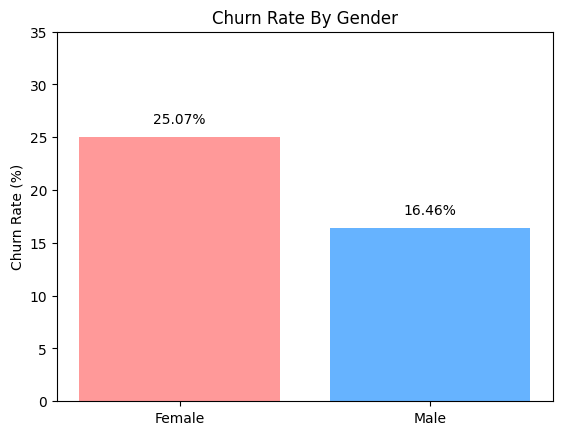

In [92]:
bars = mp.bar(churn_gender.index, churn_gender, color=['#ff9999', '#66b3ff'])

for bar in bars:
    yval = bar.get_height()
    mp.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{round(yval, 2)}%', ha='center', va='bottom')
mp.title('Churn Rate By Gender')
mp.ylabel('Churn Rate (%)')
mp.ylim(0, 35)
mp.show()

In [ ]:
# Churn rate by age group
bins = [18, 30, 40, 50, 60, 100]
labels = ['18-30', '31-40', '41-50', '51-60', '60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
 

churn_age = df.groupby('AgeGroup')['Exited'].mean() * 100
print(f'Churn Rate By Age Group : {round(churn_age,0)} %')

 

# print("\nCustomer count by Age Group:")
# print(df['AgeGroup'].value_counts().sort_index())

Churn Rate By Age Group : AgeGroup
18-30     8.0
31-40    12.0
41-50    34.0
51-60    56.0
60+      25.0
Name: Exited, dtype: float64 %


C:\Users\DELL\AppData\Local\Temp\ipykernel_9968\354756259.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.barplot(x=churn_age.index, y=churn_age.values, palette="viridis")


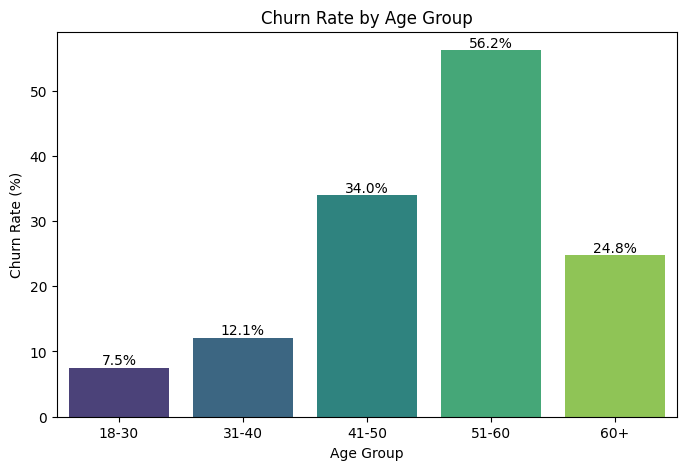

In [106]:
mp.figure(figsize=(8, 5))
ax = sb.barplot(x=churn_age.index, y=churn_age.values, palette="viridis")
mp.title("Churn Rate by Age Group")
mp.xlabel("Age Group")
mp.ylabel("Churn Rate (%)")
for bar in ax.containers:
    ax.bar_label(bar, fmt='%.1f%%')
mp.show()

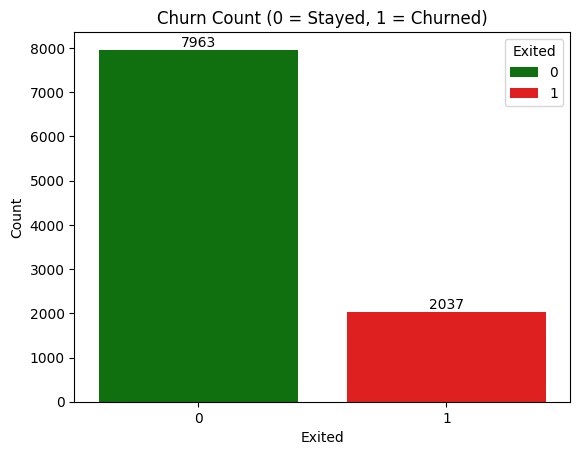

In [100]:
ax=sb.countplot(x="Exited", data=df, hue="Exited" ,palette=["green", "red"])
mp.title("Churn Count (0 = Stayed, 1 = Churned)")
mp.xlabel("Exited")
mp.ylabel("Count")
for bars in ax.containers:
    ax.bar_label(bars)
mp.show()


Above graph shows how many customers left the bank versus how many stayed.

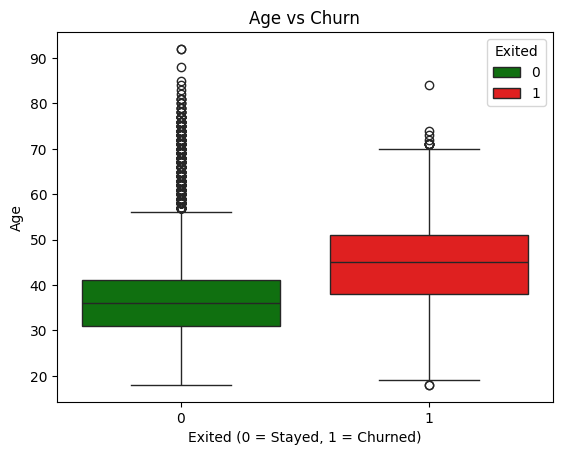

In [ ]:
sb.boxplot(x="Exited", y="Age", data=df ,hue="Exited",palette=["green", "red"])
mp.title("Age vs Churn")
mp.xlabel("Exited (0 = Stayed, 1 = Churned)")
mp.ylabel("Age")
mp.show()

 Above graph shows that customers who left the bank are generally older than customers who stayed.

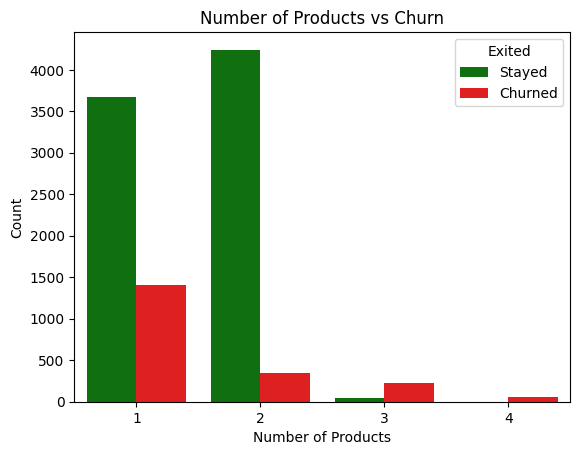

In [ ]:
sb.countplot(x="NumOfProducts", hue="Exited", data=df, palette=["green", "red"])
mp.title("Number of Products vs Churn")
mp.xlabel("Number of Products")
mp.ylabel("Count")
mp.legend(title="Exited", labels=["Stayed", "Churned"])
mp.show()

 Above graph shows that customers with 3 or 4 products are more likely to leave compared to customers with 1 or 2 products.

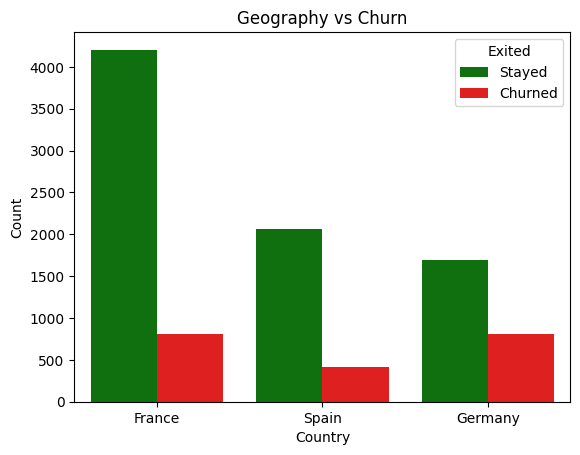

In [ ]:
sb.countplot(x="Geography", hue="Exited", data=df, palette=["green", "red"])
mp.title("Geography vs Churn")
mp.xlabel("Country")
mp.ylabel("Count")
mp.legend(title="Exited", labels=["Stayed", "Churned"])
mp.show()

Above graph shows that customers from Germany leave the bank more often compared to France and Spain.

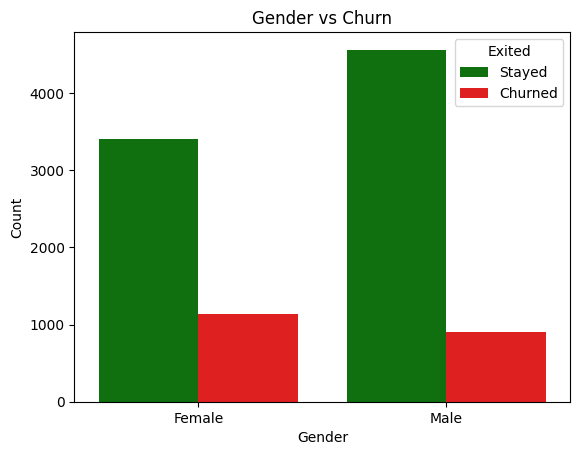

In [ ]:
sb.countplot(x="Gender", hue="Exited", data=df, palette=["green", "red"])
mp.title("Gender vs Churn")
mp.xlabel("Gender")
mp.ylabel("Count")
mp.legend(title="Exited", labels=["Stayed", "Churned"])
mp.show()

Above graph shows that female customers leave the bank more often than male customers.

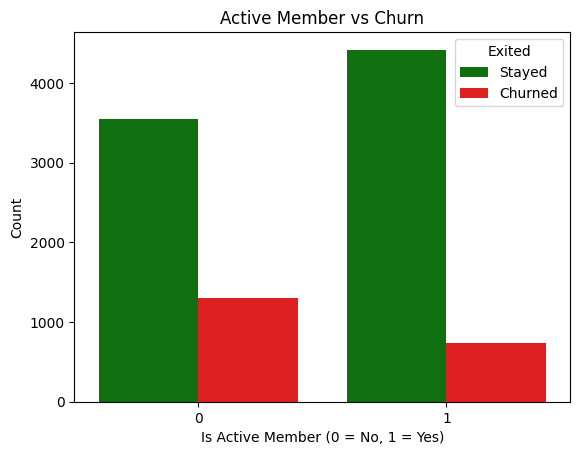

In [ ]:
sb.countplot(x="IsActiveMember", hue="Exited", data=df, palette=["green", "red"])
mp.title("Active Member vs Churn")
mp.xlabel("Is Active Member (0 = No, 1 = Yes)")
mp.ylabel("Count")
mp.legend(title="Exited", labels=["Stayed", "Churned"])
mp.show()

Above graph shows that customers who are not active with the bank are more likely to leave.

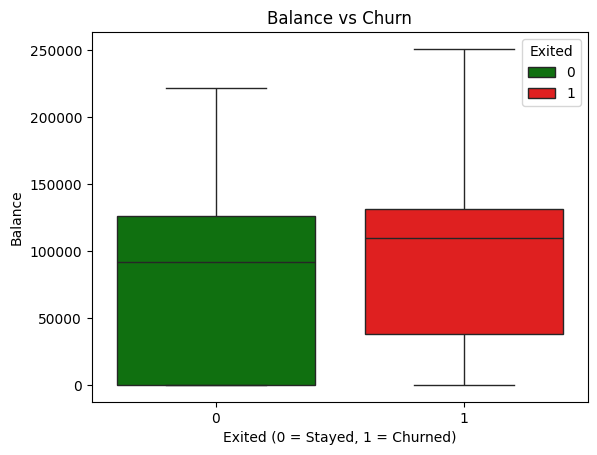

In [ ]:
sb.boxplot(x="Exited", y="Balance", data=df,hue="Exited" ,palette=["green", "red"])
mp.title("Balance vs Churn")
mp.xlabel("Exited (0 = Stayed, 1 = Churned)")
mp.ylabel("Balance")
mp.show()

Above graph shows that customers who leave the bank has higher account balance than those who stayed.

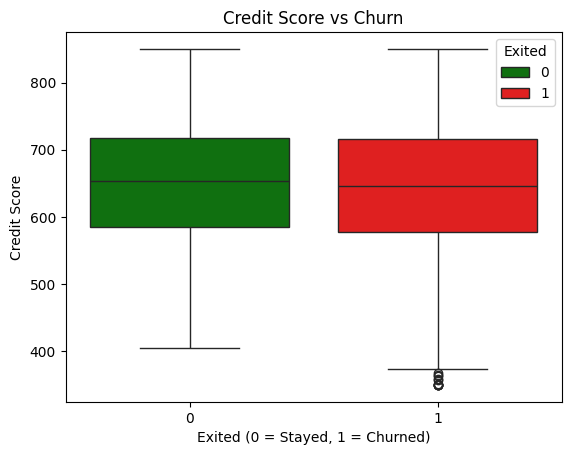

In [ ]:
sb.boxplot(x="Exited", y="CreditScore", data=df, hue="Exited" ,palette=["green", "red"])
mp.title("Credit Score vs Churn")
mp.xlabel("Exited (0 = Stayed, 1 = Churned)")
mp.ylabel("Credit Score")
mp.show()

Above graph shows that credit score has very little difference between those who stayed and those who left . 

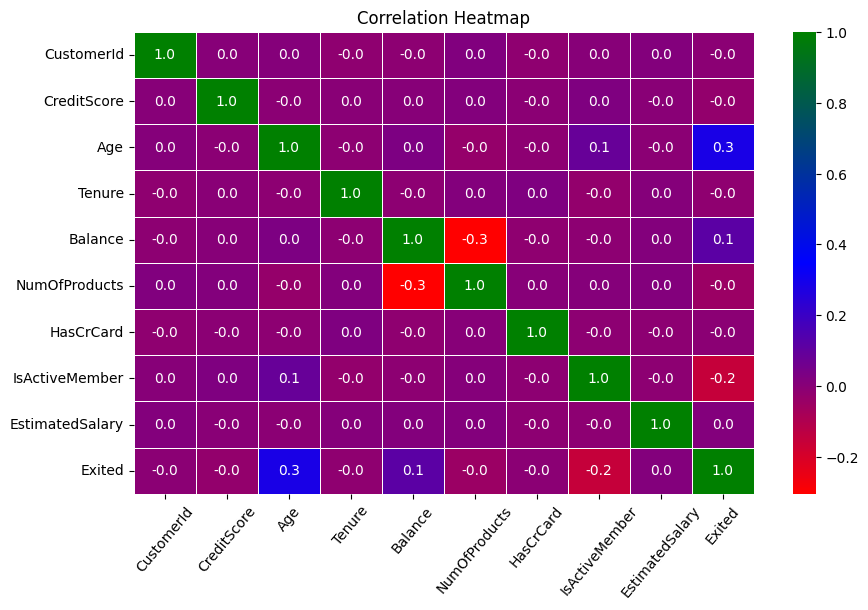

In [ ]:
df=pd.read_csv("Churn_Modelling.csv")
df = df.drop(columns=["RowNumber"])
colors = ["red", "blue", "green"]
mp.figure(figsize=(10, 6))
my_cmap = LinearSegmentedColormap.from_list("mycolors", colors)
sb.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f", cmap=my_cmap, linewidths=0.5)
mp.title("Correlation Heatmap")
mp.xticks(rotation=50)
mp.show()

Above graph shows which features are related to each other and how strongly they are connected.

After looking at all the charts, here are the key insights:

Age - Older customers are more likely to leave the bank.

Number of Products — Customers with 3 or 4 products almost always leave.

Geography - Germany has the highest number of customers leaving.

Gender - Female customers leave more than male customers.

Active Member - Customers who don't use the bank actively tend to leave.

Balance - Customers with higher balance are more likely to leave.

Credit Score - Has no strong impact on whether a customer leaves or stays.


Overall, the bank should focus on age, number of products, geography, and active membership as these are the biggest reasons why customers are leaving.
